# Baseline Retrieval — TF-IDF

## What is TF-IDF?

**TF-IDF (Term Frequency – Inverse Document Frequency)** is a classic information retrieval technique that scores documents by how relevant their words are to a query:

- **TF (Term Frequency):** How often a term appears in a document — more occurrences → higher weight
- **IDF (Inverse Document Frequency):** Down-weights terms that appear in many documents (e.g. 'the', 'patient') and up-weights specialized terms (e.g. 'arthroscopy', 'colonoscopy')

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{DF}(t)}$$

### Why TF-IDF as a baseline?
- Simple, fast, interpretable, with no GPU or embeddings needed
- Works well when query terms literally appear in the documents
- Provides a clear performance floor for comparison with dense (semantic) retrieval

### Known limitations
- No synonym understanding as 'stomach ache' won't match 'epigastric pain'
- No semantic reasoning since it can't connect 'trouble peeing' to 'urinary retention'
- Acts for a bag-of-words, ignoring word order and context

In [1]:
import pickle
import json
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# allow imports from project root
sys.path.insert(0, os.path.abspath(".."))

from src.retrieval import TFIDFRetriever, evaluate_queries

# load pre-chunked corpus
with open("../data/chunks.pkl", "rb") as f:
    chunks = pickle.load(f)

print(f"Corpus size:      {len(chunks):,} chunks")

# build retriever
retriever = TFIDFRetriever(chunks, k=3)
print(f"Vocabulary size:  {retriever.get_vocabulary_size():,} terms")
print(f"TF-IDF matrix:    {retriever.tfidf_matrix.shape}")

Corpus size:      38,838 chunks
Vocabulary size:  20,000 terms
TF-IDF matrix:    (38838, 20000)


## Single query temo — Direct vs Synonym

I compared a direct query (clinical terminology) that TF-IDF should handle well against a synonym query where it should struggle.

In [2]:
def show_results(title, query, results):
    """Pretty-print retrieval results."""
    print(f"{'='*70}")
    print(f"  {title}")
    print(f"  Query: \"{query}\"")
    print(f"{'='*70}")
    for i, r in enumerate(results, 1):
        specialty = r["metadata"]["medical_specialty"]
        score = r["score"]
        text_preview = r["text"][:150].replace("\n", " ")
        print(f"\n  #{i}  [score={score:.4f}]  Specialty: {specialty}")
        print(f"       {text_preview}...")
    print()

direct_query = "colonoscopy with biopsy for suspected polyps"
direct_results = retriever.retrieve(direct_query)
show_results("DIRECT QUERY (clinical terms)", direct_query, direct_results)

synonym_query = "stomach ache and feeling sick after eating"
synonym_results = retriever.retrieve(synonym_query)
show_results("SYNONYM QUERY (lay terms)", synonym_query, synonym_results)

  DIRECT QUERY (clinical terms)
  Query: "colonoscopy with biopsy for suspected polyps"

  #1  [score=0.3333]  Specialty: Surgery
       PROCEDURES:,  Esophagogastroduodenoscopy and colonoscopy with biopsy and polypectomy.,REASON FOR PROCEDURE: , Child with abdominal pain and rectal ble...

  #2  [score=0.3333]  Specialty: Gastroenterology
       PROCEDURES:,  Esophagogastroduodenoscopy and colonoscopy with biopsy and polypectomy.,REASON FOR PROCEDURE: , Child with abdominal pain and rectal ble...

  #3  [score=0.2790]  Specialty: Surgery
       PROCEDURES:,1.  Esophagogastroduodenoscopy.,2.  Colonoscopy with polypectomy.,PREOPERATIVE DIAGNOSES:,1.  History of esophageal cancer.,2.  History of...

  SYNONYM QUERY (lay terms)
  Query: "stomach ache and feeling sick after eating"

  #1  [score=0.1736]  Specialty: Nephrology
       .  She had no clue as to seeing Dr. XYZ again.  She says she is still not feeling very well and feels somewhat sick like.  She has no clue as to still...

  #2

## Which terms TF-IDF considers most important for a query, and visualize the term overlap between query and retrieved documents

In [3]:
# Top terms for the direct query
top_terms = retriever.get_top_terms(direct_query, n=10)
print("Top TF-IDF terms for direct query:")
for term, weight in top_terms:
    print(f"  {term:25s}  {weight:.4f}")

print()

# Top terms for the synonym query
top_terms_syn = retriever.get_top_terms(synonym_query, n=10)
print("Top TF-IDF terms for synonym query:")
for term, weight in top_terms_syn:
    print(f"  {term:25s}  {weight:.4f}")

Top TF-IDF terms for direct query:
  colonoscopy with           0.4846
  with biopsy                0.4593
  suspected                  0.4097
  polyps                     0.3838
  colonoscopy                0.3579
  biopsy                     0.2936
  for                        0.1268
  with                       0.0933

Top TF-IDF terms for synonym query:
  sick                       0.5483
  eating                     0.4812
  feeling                    0.4626
  stomach                    0.4291
  after                      0.2490
  and                        0.0881


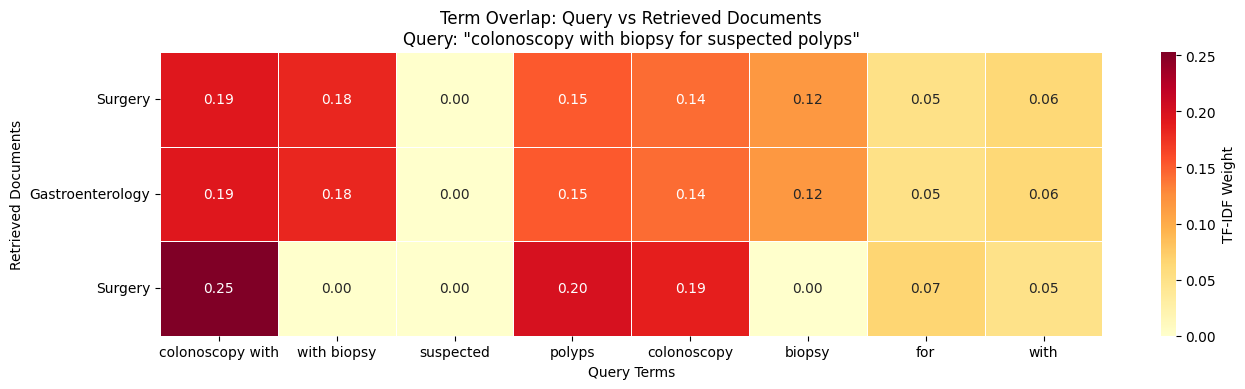

In [4]:
# Term overlap heatmap between direct query and its top-3 results
query_for_heatmap = direct_query
results_for_heatmap = direct_results

# Get query terms that have non-zero TF-IDF weight
query_terms = [t for t, w in retriever.get_top_terms(query_for_heatmap, n=15) if w > 0]

# For each result, check TF-IDF weight of query terms in that document
feature_names = list(retriever.vectorizer.get_feature_names_out())
heatmap_data = []
labels = []

for i, r in enumerate(results_for_heatmap):
    doc_idx = None
    for j, c in enumerate(chunks):
        if c["text"] == r["text"]:
            doc_idx = j
            break
    if doc_idx is None:
        continue

    doc_vec = retriever.tfidf_matrix[doc_idx].toarray().flatten()
    row = []
    for term in query_terms:
        if term in feature_names:
            idx = feature_names.index(term)
            row.append(doc_vec[idx])
        else:
            row.append(0.0)
    heatmap_data.append(row)
    labels.append(f"{r['metadata']['medical_specialty']}")

heatmap_df = pd.DataFrame(heatmap_data, index=labels, columns=query_terms)

fig, ax = plt.subplots(figsize=(19, 4.5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "TF-IDF Weight"})
ax.set_title(f'Term Overlap: Query vs Retrieved Documents\nQuery: "{query_for_heatmap}"')
ax.set_xlabel("Query Terms")
ax.set_ylabel("Retrieved Documents")
plt.setp(ax.get_yticklabels(), rotation=0, ha="right")
plt.subplots_adjust(left=0.28, bottom=0.25)
plt.show()

## Full evaluation: 30 test queries: 10 direct, 10 synonym, 10 complex

In [5]:
# Load test queries
with open("../data/test_queries.json") as f:
    test_queries = json.load(f)

# Run full evaluation
results_df = evaluate_queries(retriever, test_queries, k=3)

# Add a column with the actual top-3 retrieved specialties for visibility
retrieved_specialties = []
for q in test_queries:
    results = retriever.retrieve(q["query"], k=3)
    specs = [r["metadata"]["medical_specialty"] for r in results]
    retrieved_specialties.append(" | ".join(specs))
results_df["top_3_retrieved"] = retrieved_specialties

# Display with wider columns so you can read the retrieved specialties
pd.set_option("display.max_colwidth", 80)
results_df[["id", "query", "category", "expected_specialty", "top_3_retrieved",
            "precision_at_k", "hit_at_k", "mrr"]]

,id,query,category,expected_specialty,top_3_retrieved,precision_at_k,hit_at_k,mrr
0,q01,patient with chest pain and shortness of breath on exertion,direct,Cardiovascular / Pulmonary,Consult - History and Phy. | Cardiovascular / Pulmonary | General Medicine,0.333333,1,0.5
1,q02,right knee arthroscopy for torn meniscus,direct,Orthopedic,Orthopedic | Surgery | Orthopedic,0.666667,1,1.0
2,q03,colonoscopy with biopsy for suspected polyps,direct,Gastroenterology,Surgery | Gastroenterology | Surgery,0.333333,1,0.5
3,q04,MRI of the lumbar spine with contrast,direct,Radiology,Consult - History and Phy. | Neurology | Orthopedic,0.000000,0,0.0
4,q05,laparoscopic cholecystectomy for gallstones,direct,Surgery,Discharge Summary | Gastroenterology | Gastroenterology,0.000000,0,0.0
5,q06,cystoscopy for recurrent urinary tract infections,direct,Urology,Surgery | Urology | General Medicine,0.333333,1,0.5
6,q07,cesarean section delivery due to fetal distress,direct,Obstetrics / Gynecology,Surgery | Obstetrics / Gynecology | Surgery,0.333333,1,0.5
7,q08,EEG for seizure disorder evaluation,direct,Neurology,Consult - History and Phy. | Neurology | Psychiatry / Psychology,0.333333,1,0.5
8,q09,tonsillectomy and adenoidectomy for chronic tonsillitis,direct,ENT - Otolaryngology,Surgery | ENT - Otolaryngology | ENT - Otolaryngology,0.666667,1,0.5
9,q10,bone marrow biopsy for suspected leukemia,direct,Hematology - Oncology,SOAP / Chart / Progress Notes | Hematology - Oncology | Hematology - Oncology,0.666667,1,0.5


## Metrics summary

In [7]:
summary = results_df.groupby("category").agg(
    precision_at_3=("precision_at_k", "mean"),
    hit_rate_at_3=("hit_at_k", "mean"),
    mrr=("mrr", "mean"),
).reindex(["direct", "synonym", "complex"])

# Add overall row
overall = pd.DataFrame({
    "precision_at_3": [results_df["precision_at_k"].mean()],
    "hit_rate_at_3": [results_df["hit_at_k"].mean()],
    "mrr": [results_df["mrr"].mean()],
}, index=["OVERALL"])

summary = pd.concat([summary, overall])
print("Metrics Summary (TF-IDF Baseline, k=3)")
print("=" * 50)
summary.round(3)

Metrics Summary (TF-IDF Baseline, k=3)


,precision_at_3,hit_rate_at_3,mrr
direct,0.367,0.8,0.45
synonym,0.033,0.1,0.05
complex,0.300,0.6,0.55
OVERALL,0.233,0.5,0.35


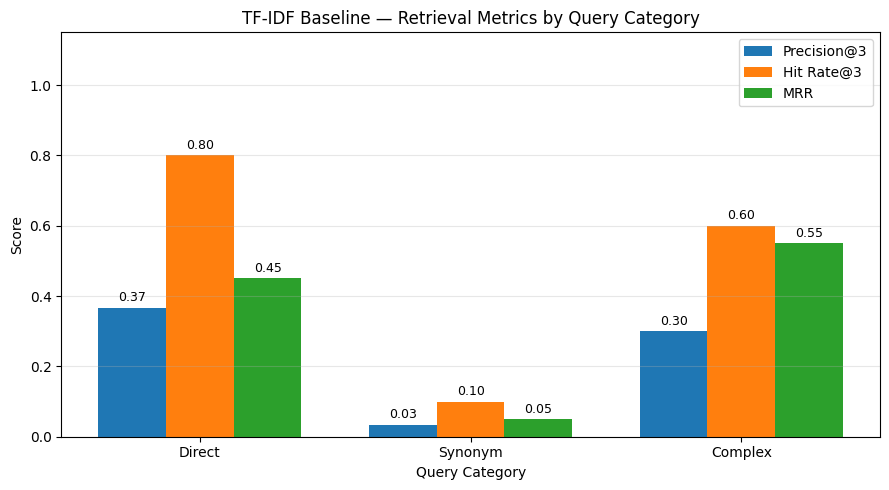

In [8]:
# Grouped bar chart of metrics by category
categories = ["direct", "synonym", "complex"]
metrics = ["precision_at_3", "hit_rate_at_3", "mrr"]
metric_labels = ["Precision@3", "Hit Rate@3", "MRR"]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [summary.loc[cat, metric] for cat in categories]
    bars = ax.bar(x + i * width, values, width, label=label)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Query Category")
ax.set_ylabel("Score")
ax.set_title("TF-IDF Baseline — Retrieval Metrics by Query Category")
ax.set_xticks(x + width)
ax.set_xticklabels([c.capitalize() for c in categories])
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Failure analysis
The query uses lay terms that don't appear in clinical transcriptions. TF-IDF can only match on literal word overlap.

In [10]:
# Find queries that missed completely (hit_at_k == 0)
failures = results_df[results_df["hit_at_k"] == 0].copy()
print(f"Total failures: {len(failures)} / {len(results_df)}")
print(f"By category: {failures['category'].value_counts().to_dict()}")
print()

# Pick one failure from each category when possible
failure_queries = {q["id"]: q for q in test_queries}
picks = []
for cat in ["synonym", "complex", "direct"]:
    sub = failures[failures["category"] == cat]
    if len(sub) > 0:
        picks.append(sub.iloc[0])

for row in picks:
    q = failure_queries[row["id"]]
    results = retriever.retrieve(q["query"], k=3)
    top_terms = [t for t, _ in retriever.get_top_terms(q["query"], n=5)]
    retrieved = " | ".join(
        f"{r['metadata']['medical_specialty']} ({r['score']:.2f})" for r in results
    )
    print(f"[{row['category'].upper()}] {q['query']}")
    print(f"  Expected:  {q['expected_specialty']}")
    print(f"  Retrieved: {retrieved}")
    print(f"  Top terms: {', '.join(top_terms)}")
    print()

Total failures: 15 / 30
By category: {'synonym': 9, 'complex': 4, 'direct': 2}

[SYNONYM] stomach ache and feeling sick after eating
  Expected:  Gastroenterology
  Retrieved: Nephrology (0.17) | SOAP / Chart / Progress Notes (0.17) | SOAP / Chart / Progress Notes (0.16)
  Top terms: sick, eating, feeling, stomach, after

[COMPLEX] numbness in legs after back injury with bladder dysfunction
  Expected:  Neurology
  Retrieved: Consult - History and Phy. (0.22) | Chiropractic (0.22) | Orthopedic (0.22)
  Top terms: numbness in, dysfunction, legs, numbness, injury

[DIRECT] MRI of the lumbar spine with contrast
  Expected:  Radiology
  Retrieved: Consult - History and Phy. (0.35) | Neurology (0.35) | Orthopedic (0.32)
  Top terms: spine with, with contrast, mri of, the lumbar, lumbar spine



## Conclusions

### What works
- TF-IDF performs well on direct queries that use the same clinical vocabulary found in the transcriptions
- It is fast, interpretable, and requires no pre-trained models or GPU

### What fails
- Lay terms like 'stomach ache' have no lexical overlap with clinical terms like 'epigastric pain' or 'abdominal discomfort'
- Multi-condition queries dilute the TF-IDF signal across too many specialties and lack the semantic reasoning to prioritize the primary condition
- Some *medical_specialty* values such as 'SOAP / Chart / Progress Notes' give 'false positives'  

### Performance gap
The metrics clearly show: cnt_succes(direct) > cnt_success(complex) > cnt_success(synonym), confirming that TF-IDF's fundamental limitation is its inability to bridge vocabulary gaps.